## Imputation of time-series

Some of the code was found here for visualisation: https://cienciadedatos.net/documentos/py46-forecasting-time-series-missing-values

In [1]:
!nvidia-smi

Mon Jun  1 12:03:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:02:00.0 Off |                  Off |
|  0%   37C    P8             11W /  450W |       1MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import math
import torch
import torch.nn as nn

import argparse
import torch
import datetime
import json
import yaml
import os

import sys

sys.path.append(".")
sys.path.append("./models")

from models.mps_wrapper import MPSWrapper
from utils import *

import matplotlib.pyplot as plt


In [3]:
color = '\033[1m\033[38;5;208m' 
print(f"{color}Version numpy: {np.__version__}")
print(f"{color}Version pytorch: {torch.__version__}")

Version numpy: 2.4.6
Version pytorch: 2.12.0+cu130


### Load Data

In [4]:
#Load data
#rq: temporal resolution = 4h

from dataset_ope import get_dataloader
gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, _, test_loader, _, _ = get_dataloader(device=gpu, batch_size=8, safran_covariates=True)

parameters_name = np.loadtxt("data/ope_andra/sagd_parameters_50_hte.csv", dtype=str)

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


In [5]:
main_data = test_loader.dataset.main_data
mask_data = test_loader.dataset.mask_data

main_data[mask_data == 0] = np.nan

timepoints = test_loader.dataset.timepoints
total_length = len(main_data)

start_train = 0
end_train = total_length - test_loader.dataset.seq_length - test_loader.dataset.valid_length - test_loader.dataset.test_length + 1
train_data = main_data[start_train:end_train]

start_valid = total_length - test_loader.dataset.seq_length - test_loader.dataset.valid_length - test_loader.dataset.test_length + test_loader.dataset.pred_length
end_valid = total_length - test_loader.dataset.seq_length - test_loader.dataset.test_length + test_loader.dataset.pred_length
valid_data = main_data[start_valid:end_valid]

start_test = total_length - test_loader.dataset.seq_length - test_loader.dataset.test_length + test_loader.dataset.pred_length
end_test = total_length - test_loader.dataset.seq_length + test_loader.dataset.pred_length
test_data = main_data[start_test:end_test]

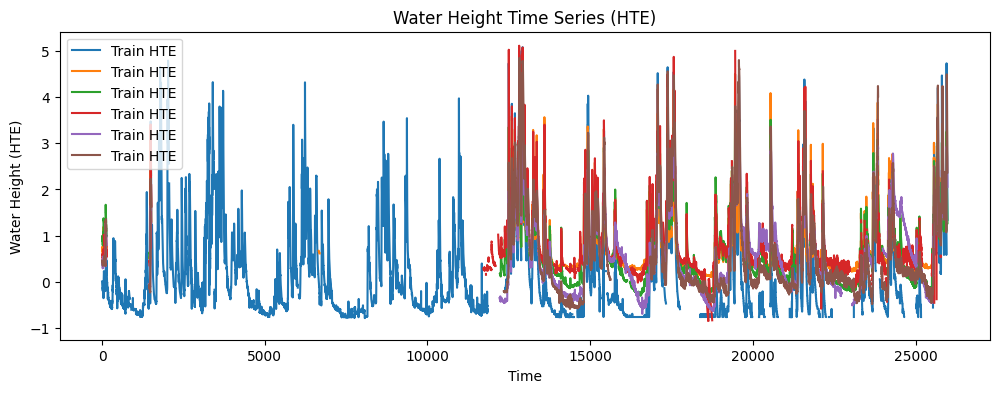

In [6]:
# Plot training hte time series where parameter name contains "hte"
hte_idx = np.where(np.char.find(parameters_name, "hte") != -1)
plt.figure(figsize=(12, 4))
plt.plot(main_data[:, hte_idx][:, 0], label="Train HTE")
plt.title("Water Height Time Series (HTE)")
plt.xlabel("Time")
plt.ylabel("Water Height (HTE)")
plt.legend()
plt.show()

In [7]:
print("train data shape:", train_data.shape)
print("valid data shape:", valid_data.shape)
print("test data shape:", test_data.shape)

train data shape: (25670, 75)
valid data shape: (120, 75)
test data shape: (168, 75)


In [8]:
covariates = np.genfromtxt('./data/ope_andra/safran_covariates.csv', delimiter=',', usemask=True, filling_values=0)
covariates_names = pd.read_csv('./data/ope_andra/safran_parameters_names.csv')

training_covariates = covariates[start_train:end_train]

indices_step1 = np.where(np.char.find(parameters_name, "hte") != -1)[0] # Old: list(range(69,75))

In [9]:
mps = MPSWrapper(training_data=train_data, parameters_name=parameters_name, indices_step1=indices_step1, covariates=training_covariates, covariate_names=covariates_names)

In [10]:
# Try loading imputation_results_ration_25.npy
try:
    imputation_results = np.load("imputation_results_ratio_25.npy", allow_pickle=True)
    print(imputation_results.shape)
    print("Loaded imputation results from file.")
except FileNotFoundError:
    print("Imputation results file not found. Running imputation...")

Imputation results file not found. Running imputation...


In [11]:
for batch in test_loader:
    observed_mask_forecast = batch['observed_mask']
    # set later half to 0
    
    print(observed_mask_forecast.shape)
    observed_mask_forecast[:, 25:] = 0
    
    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    covariates = batch['covariates']
    
    generated = mps.impute(observed_data=observed_data, observed_mask=observed_mask_forecast, covariates=covariates, n_samples=1)
    break

torch.Size([8, 24, 75])


In [12]:
print(generated.shape, observed_data.shape, observed_mask_forecast.shape)
generated_test = generated.cpu().permute([0, 1, 3, 2]).numpy()[0].squeeze()
observations = observed_data[0].squeeze().cpu().numpy()
mask = observed_mask_forecast[0].squeeze().cpu().numpy()
timestamps = batch['timepoints'][0].squeeze().numpy()
print(generated_test.shape, observations.shape, mask.shape, timestamps.shape)

torch.Size([8, 1, 75, 24]) torch.Size([8, 24, 75]) torch.Size([8, 24, 75])
(24, 75) (24, 75) (24, 75) (24,)


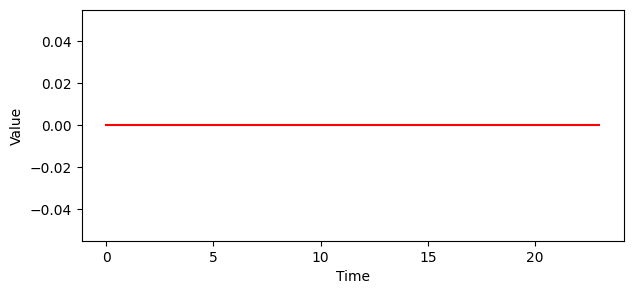

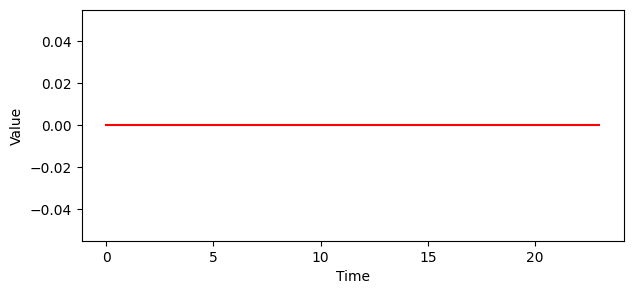

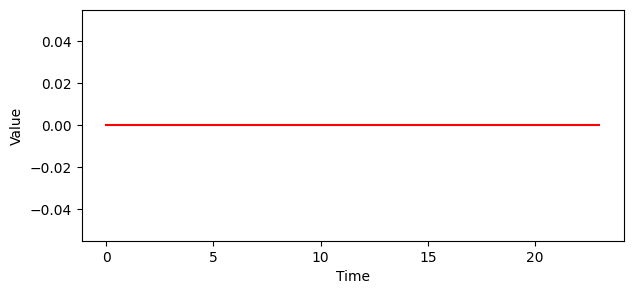

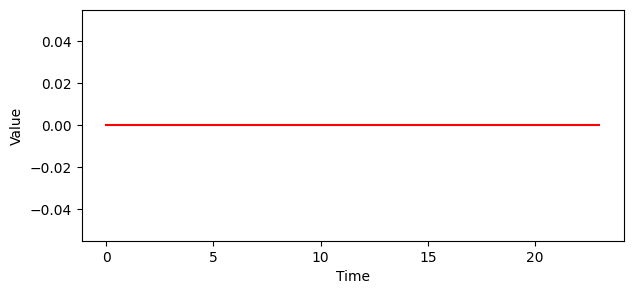

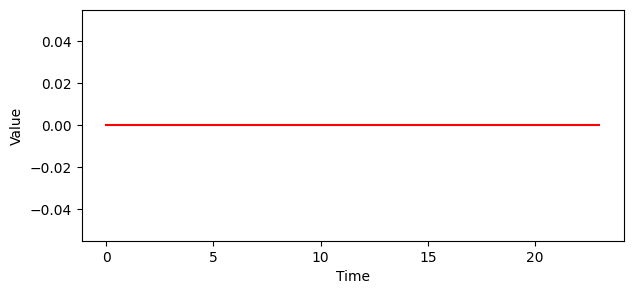

In [13]:
def find_gaps(serie_training_mask):
    """
    Return the indices of the gaps in values based on the training mask.
    """

    padded_mask = np.pad(np.logical_not(serie_training_mask).astype(int), (1,1), mode='constant', constant_values=0)

    gaps_start = np.where(np.diff(padded_mask) == 1)[0]
    gaps_end = np.where(np.diff(padded_mask) == -1)[0]

    gaps = np.array(list(zip(gaps_start, gaps_end)))

    return gaps

# Print gap filling

for i in range(5):
    fig, ax = plt.subplots(figsize=(7, 3))

    gen_squeezed = generated_test.squeeze()
    mask_squeezed = mask.squeeze()


    gaps = find_gaps(1 - mask_squeezed[:, i])
    for gap in gaps:
        if gap[1] <= len(gen_squeezed[:, i]) and gap[0] >= 0:
            ax.plot(
                np.linspace(gap[0], gap[1]-1, num=gap[1]-gap[0]),
                gen_squeezed[gap[0]:gap[1], i],
                color = 'blue',
                label = 'observations'
                )

    gaps = find_gaps(mask_squeezed[:, i])

    for gap in gaps:
        if gap[1] <= len(gen_squeezed[:, i]) and gap[0] >= 0:
            ax.plot(
                np.linspace(gap[0], gap[1]-1, num=gap[1]-gap[0]),
                gen_squeezed[gap[0]:gap[1], i],
                color = 'red',
                label = 'predictions'
                )
        
    #plt.title(test_station_name + " " +parameter_names[i])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.plot()

In [ ]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            mps,
            test_loader,
            prediction_horizon=h,
            nsample=100,
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


 25%|██▌       | 1/4 [33:24<1:40:14, 2004.89s/it, rmse_total=1.3, mae_total=0.934, smape_total=126, batch_no=1]

In [ ]:
rng = np.random.RandomState(1)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 18:] = 0.
    observed_mask_forecast = observed_mask_forecast * observed_mask

    covariates = batch['covariates']

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    generated = mps.impute(observed_data=observed_data, observed_mask=observed_mask_forecast, covariates=covariates, n_samples=100)
    real_data = torch.nan_to_num(real_data, nan=0.0)
    break

In [ ]:
generated_test = generated.permute([0, 1, 3, 2]).cpu()
X = np.arange(generated_test.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [ ]:
generated_test.shape

In [ ]:
def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,axis=dim)

qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

In [ ]:
###airquality###
dataind = 4 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')


In [ ]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

In [ ]:
# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']

    real_data = batch['observed_data']
    
    ratio_to_keep = 1. - 0.55 # 55% missing
    timesteps_to_keep = int(ratio_to_keep * observed_mask.shape[1])
    observed_mask_imputation = torch.zeros_like(observed_mask)
    for i in range(observed_mask.shape[-1]):
        rng = np.random.RandomState(i)
        observation_indices = sorted(rng.choice(np.arange(observed_mask.shape[1]), size=timesteps_to_keep, replace=False))
        observed_mask_imputation[:, observation_indices, i] = observed_mask[:, observation_indices, i]

    #print(observed_mask_imputation[0])

    covariates = batch['covariates']

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_imputation

    generated = mps.impute(observed_data=observed_data, observed_mask=observed_mask_forecast, covariates=covariates, n_samples=100)
    real_data = torch.nan_to_num(real_data, nan=0.0)
    break

X = np.arange(generated_test.shape[0]).reshape(-1, 1)
generated_test = generated.permute([0, 1, 3, 2]).cpu()

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_imputation.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_imputation.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [ ]:
qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

In [ ]:
###airquality###
dataind = 7 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')
